In [69]:
import itertools
import random
import math
import scipy.stats as ss
import numpy as np
import dendropy
from dendropy.calculate import treemeasure


In [70]:
import skbio
from skbio import DistanceMatrix
from skbio.tree import nj

In [71]:
def p_delta_change(n_states, l, change: bool):
    if not change:
        p_out = 1 / n_states + (n_states - 1) / n_states * math.exp(- (n_states - 1) * l)
    else:
        p_out = 1 / n_states - math.exp(- (n_states - 1) * l) / n_states
    return p_out

def simulate_cn_seq(prev_cn, n_states, l, alpha=1.):
    node_cn = np.empty_like(prev_cn)
    pdd = p_delta_change(n_states, alpha * l, change=False)
    u = random.random()
    if u < pdd:
        node_cn[0] = prev_cn[0]
    else:
        node_cn[0] = random.choice([j for j in range(n_states) if j != prev_cn[0]])

    for m in range(1, len(prev_cn)):
        u = random.random()
        no_change_cn = prev_cn[m] - prev_cn[m-1] + node_cn[m-1]
        if 0 <= no_change_cn < n_states:
            if u < pdd:
                node_cn[m] = no_change_cn
            else:
                node_cn[m] = random.choice([j for j in range(n_states) if j != no_change_cn])
        else:
            node_cn[m] = random.choice([j for j in range(n_states)])
    return node_cn

def simulate_cn(tree, n_sites, n_states, alpha=1.):
    cn = np.empty((len(tree.nodes()), n_sites))
    cn[0, :] = 2
    assert tree.seed_node.label is not None
    for n in tree.preorder_node_iter():
        if n.label != 0:
            cn[n.label] = simulate_cn_seq(cn[n.parent_node.label], n_states, n.edge_length, alpha=alpha)
    return cn

def emit_normalized_obs(cn_seq, mu=1.0, scale=1.0):
    eps = ss.norm(loc=0., scale=scale).rvs(size=len(cn_seq))
    return np.clip(cn_seq / mu + eps, a_min=0., a_max=None)

def emit_raw_obs(cn_seq, lam=100.):
    return ss.poisson.rvs(mu=np.clip(cn_seq, a_min=.01, a_max=None) * lam, size=len(cn_seq))

def label_tree(tree):
    for i, n in enumerate(tree.preorder_node_iter()):
        n.label = i

def rand_dataset(n_cells: int, n_states: int, n_sites: int, alpha=0.02, obs_type='norm') -> dict:
    tree = dendropy.treesim.treesim.birth_death_tree(birth_rate=0.9, death_rate=0.4, num_extant_tips=n_cells)
    label_tree(tree)
    cn = simulate_cn(tree, n_sites, n_states, alpha=alpha)
    obs = np.empty((n_sites, n_cells))
    tax_id_map = {}
    for i, t in enumerate(tree.leaf_node_iter()):
        tax_id_map[t.taxon] = i
        if obs_type == 'pois':
            obs[:, i] = emit_raw_obs(cn[t.label])
        elif obs_type == 'norm':
            obs[:, i] = emit_normalized_obs(cn[t.label], scale=.7)
    data = {
        'obs': obs,
        'tree': tree,
        'cn': cn,
        'tax_id_map': tax_id_map
    }
    return data

def get_distance_matrix(tree):
    taxa = list(tree.taxon_namespace)
    pdc = tree.phylogenetic_distance_matrix()
    n = len(taxa)
    dist_matrix = np.zeros((n, n))
    for i, t1 in enumerate(taxa):
        for j, t2 in enumerate(taxa):
            if i != j:
                dist_matrix[i, j] = pdc(t1, t2)
    return dist_matrix

In [75]:
# Generate dataset

data = rand_dataset(20, 8, 10)
tree = data['tree']


In [76]:
# Calculate the initial distance matrix

initial_dist_matrix = get_distance_matrix(tree)
# print("Initial Distance Matrix:")
# print(initial_dist_matrix)


Initial Distance Matrix:
[[0.00000000e+00 4.88021248e+00 2.15287434e+00 3.12623939e+00
  3.12623939e+00 2.15287434e+00 4.88021248e+00 3.12623939e+00
  3.12623939e+00 3.12623939e+00 4.88021248e+00 4.88021248e+00
  9.99458537e-01 4.88021248e+00 3.12623939e+00 3.12623939e+00
  2.15287434e+00 4.88021248e+00 4.88021248e+00 4.88021248e+00]
 [4.88021248e+00 0.00000000e+00 4.88021248e+00 4.88021248e+00
  4.88021248e+00 4.88021248e+00 2.45149789e+00 4.88021248e+00
  4.88021248e+00 4.88021248e+00 2.76505311e+00 2.76505311e+00
  4.88021248e+00 2.43979883e-01 4.88021248e+00 4.88021248e+00
  4.88021248e+00 2.76505311e+00 2.76505311e+00 2.76505311e+00]
 [2.15287434e+00 4.88021248e+00 0.00000000e+00 3.12623939e+00
  3.12623939e+00 6.37351609e-01 4.88021248e+00 3.12623939e+00
  3.12623939e+00 3.12623939e+00 4.88021248e+00 4.88021248e+00
  2.15287434e+00 4.88021248e+00 3.12623939e+00 3.12623939e+00
  2.88086547e-01 4.88021248e+00 4.88021248e+00 4.88021248e+00]
 [3.12623939e+00 4.88021248e+00 3.12623939

In [96]:
# ids = []
# for i, leaf in enumerate(tree.leaf_node_iter(), start=1):
#     label = f"T{i}: {leaf.taxon.label}"
#     ids.append(label)

In [97]:
ids_new= []
for i, leaf in enumerate(tree.leaf_node_iter(), start=1):
    label = f"{leaf.taxon.label}"
    ids_new.append(label)

In [101]:
# type(ids_new)

list

In [80]:
# print("List of T_1 to T_ncells:")
# for id_label in ids:
#     print(id_label)

List of T_1 to T_ncells:
T1: T10
T2: T15
T3: T8
T4: T4
T5: T16
T6: T9
T7: T5
T8: T13
T9: T1
T10: T6
T11: T3
T12: T17
T13: T18
T14: T12
T15: T11
T16: T20
T17: T19
T18: T7
T19: T14
T20: T2


In [81]:
# Prepare the labels for scikit-bio

# labels = [f"T_{i+1}" for i in range(len(tree.leaf_nodes()))]


In [102]:
# Create a DistanceMatrix -> scikit-bio

dm_skbio = DistanceMatrix(initial_dist_matrix, ids_new)

In [103]:
# Perform NJ algorithm using scikit-bio

nj_tree = nj(dm_skbio)
# print(nj_tree)


((T1:0.055309,(T11:0.147436,(T16:0.692347,(T6:1.306848,(((T5:1.225749,(T12:0.12199,T15:0.12199):1.103759):0.156778,(T14:1.290894,(T2:0.90205,(T3:0.378367,(T7:0.092944,T17:0.092944):0.285422):0.523684):0.388843):0.091633):1.934566,((T9:0.318676,(T19:0.144043,T8:0.144043):0.174633):0.757761,(T18:0.499729,T10:0.499729):0.576708):0.486683):0.256271):0.614502):0.544911):0.092126):0.054727,(T13:0.0,T4:0.0):0.000583,T20:0.000583);



In [104]:
# Compare the NJ tree to the initial tree

nj_tree_newick = nj_tree.write('NJTree')
# print("NJ Tree Newick format:")
# print(nj_tree_newick)

NJ Tree Newick format:
NJTree


In [107]:
NJ_DM= DistanceMatrix(initial_dist_matrix, ids_new)

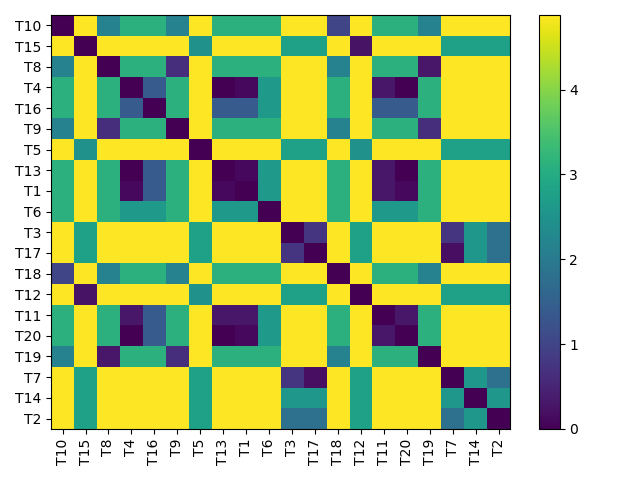

In [108]:
NJ_DM

In [125]:
# nj_labels = [node.name for node in nj_tree.tips()]


In [112]:
# Calculate the distance matrix for the NJ tree

nj_tree_skbio = skbio.TreeNode.read(nj_tree_newick)
nj_dist_matrix = nj_tree_skbio.tip_tip_distances(ids_new)
# print("NJ Distance Matrix:")
# print(nj_dist_matrix)


NJ Distance Matrix:
20x20 distance matrix
IDs:
'T10', 'T15', 'T8', 'T4', 'T16', 'T9', 'T5', 'T13', 'T1', 'T6', 'T3', 'T17', ...
Data:
[[0.000000e+00 4.880213e+00 2.152874e+00 3.126240e+00 3.126240e+00
  2.152874e+00 4.880213e+00 3.126240e+00 3.126239e+00 3.126239e+00
  4.880213e+00 4.880212e+00 9.994580e-01 4.880213e+00 3.126240e+00
  3.126240e+00 2.152874e+00 4.880212e+00 4.880213e+00 4.880212e+00]
 [4.880213e+00 0.000000e+00 4.880213e+00 4.880213e+00 4.880213e+00
  4.880213e+00 2.451498e+00 4.880213e+00 4.880212e+00 4.880212e+00
  2.765054e+00 2.765053e+00 4.880213e+00 2.439800e-01 4.880213e+00
  4.880213e+00 4.880213e+00 2.765053e+00 2.765054e+00 2.765053e+00]
 [2.152874e+00 4.880213e+00 0.000000e+00 3.126240e+00 3.126240e+00
  6.373520e-01 4.880213e+00 3.126240e+00 3.126239e+00 3.126239e+00
  4.880213e+00 4.880212e+00 2.152874e+00 4.880213e+00 3.126240e+00
  3.126240e+00 2.880860e-01 4.880212e+00 4.880213e+00 4.880212e+00]
 [3.126240e+00 4.880213e+00 3.126240e+00 0.000000e+00 1.384

In [113]:
nj_dist_matrix_array = nj_dist_matrix.to_data_frame().to_numpy()


In [132]:
# Compare the two distance matrices

difference = np.abs(initial_dist_matrix - nj_dist_matrix_array)
print("Difference between Initial and NJ Distance Matrices:")
print(difference)


Difference between Initial and NJ Distance Matrices:
[[0.00000000e+00 5.18129335e-07 3.42800284e-07 6.11447015e-07
  6.11447015e-07 3.42800284e-07 5.18129335e-07 6.11447015e-07
  3.88552985e-07 3.88552985e-07 5.18129335e-07 4.81870664e-07
  5.36677221e-07 5.18129335e-07 6.11447015e-07 6.11447015e-07
  3.42800284e-07 4.81870664e-07 5.18129334e-07 4.81870664e-07]
 [5.18129335e-07 0.00000000e+00 5.18129335e-07 5.18129335e-07
  5.18129335e-07 5.18129335e-07 1.11936967e-07 5.18129335e-07
  4.81870664e-07 4.81870664e-07 8.88741479e-07 1.11258522e-07
  5.18129335e-07 1.16521358e-07 5.18129335e-07 5.18129335e-07
  5.18129335e-07 1.11258522e-07 8.88741478e-07 1.11258522e-07]
 [3.42800284e-07 5.18129335e-07 0.00000000e+00 6.11447014e-07
  6.11447015e-07 3.90535414e-07 5.18129335e-07 6.11447014e-07
  3.88552986e-07 3.88552985e-07 5.18129335e-07 4.81870664e-07
  3.42800284e-07 5.18129335e-07 6.11447014e-07 6.11447014e-07
  5.46555297e-07 4.81870664e-07 5.18129334e-07 4.81870664e-07]
 [6.11447015e-

In [133]:
is_close_to_zero = np.allclose(difference, 0, atol=1e-5)
print(is_close_to_zero)

True


In [134]:
# Print the distances between every two taxa in true tree

print("\nDistances between taxa before NJ:")
for i, t1 in enumerate(ids_new):
    for j, t2 in enumerate(ids_new):
        if i < j:
            print(f"Distance between {t1} and {t2}: {initial_dist_matrix[i, j]}")



Distances between taxa before NJ:
Distance between T10 and T15: 4.8802124818706645
Distance between T10 and T8: 2.1528743428002834
Distance between T10 and T4: 3.126239388552985
Distance between T10 and T16: 3.126239388552985
Distance between T10 and T9: 2.1528743428002834
Distance between T10 and T5: 4.8802124818706645
Distance between T10 and T13: 3.126239388552985
Distance between T10 and T1: 3.126239388552985
Distance between T10 and T6: 3.126239388552985
Distance between T10 and T3: 4.8802124818706645
Distance between T10 and T17: 4.8802124818706645
Distance between T10 and T18: 0.9994585366772213
Distance between T10 and T12: 4.8802124818706645
Distance between T10 and T11: 3.126239388552985
Distance between T10 and T20: 3.126239388552985
Distance between T10 and T19: 2.1528743428002834
Distance between T10 and T7: 4.8802124818706645
Distance between T10 and T14: 4.880212481870665
Distance between T10 and T2: 4.8802124818706645
Distance between T15 and T8: 4.8802124818706645
Dis

In [135]:
# Print the distances between every two taxa after NJ
print("\nDistances between taxa after NJ:")
for i, t1 in enumerate(ids_new):
    for j, t2 in enumerate(ids_new):
        if i < j:
            print(f"Distance between {t1} and {t2}: {nj_dist_matrix_array[i, j]}")



Distances between taxa after NJ:
Distance between T10 and T15: 4.8802129999999995
Distance between T10 and T8: 2.1528739999999997
Distance between T10 and T4: 3.1262399999999997
Distance between T10 and T16: 3.12624
Distance between T10 and T9: 2.1528739999999997
Distance between T10 and T5: 4.8802129999999995
Distance between T10 and T13: 3.1262399999999997
Distance between T10 and T1: 3.1262389999999995
Distance between T10 and T6: 3.126239
Distance between T10 and T3: 4.8802129999999995
Distance between T10 and T17: 4.880212
Distance between T10 and T18: 0.999458
Distance between T10 and T12: 4.8802129999999995
Distance between T10 and T11: 3.1262399999999997
Distance between T10 and T20: 3.1262399999999997
Distance between T10 and T19: 2.1528739999999997
Distance between T10 and T7: 4.880212
Distance between T10 and T14: 4.8802129999999995
Distance between T10 and T2: 4.880212
Distance between T15 and T8: 4.8802129999999995
Distance between T15 and T4: 4.8802129999999995
Distance 

In [136]:
np.allclose(initial_dist_matrix, nj_dist_matrix_array, rtol=1e-05, atol=1e-05)

True

In [141]:
nj_tree = nj(NJ_DM)
print(nj_tree)

((T1:0.055309,(T11:0.147436,(T16:0.692347,(T6:1.306848,(((T5:1.225749,(T12:0.12199,T15:0.12199):1.103759):0.156778,(T14:1.290894,(T2:0.90205,(T3:0.378367,(T7:0.092944,T17:0.092944):0.285422):0.523684):0.388843):0.091633):1.934566,((T9:0.318676,(T19:0.144043,T8:0.144043):0.174633):0.757761,(T18:0.499729,T10:0.499729):0.576708):0.486683):0.256271):0.614502):0.544911):0.092126):0.054727,(T13:0.0,T4:0.0):0.000583,T20:0.000583);

